In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import (linkage, dendrogram, fcluster)
from sklearn.cluster import AgglomerativeClustering

In [3]:
# Load cleaned data

filepath = "../data/spike_waveforms_clean.csv"
df = pd.read_csv(
    filepath,
    header=None
)
print(df.shape)

(26862, 62)


In [4]:
# Standardize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled.shape)

(26862, 62)


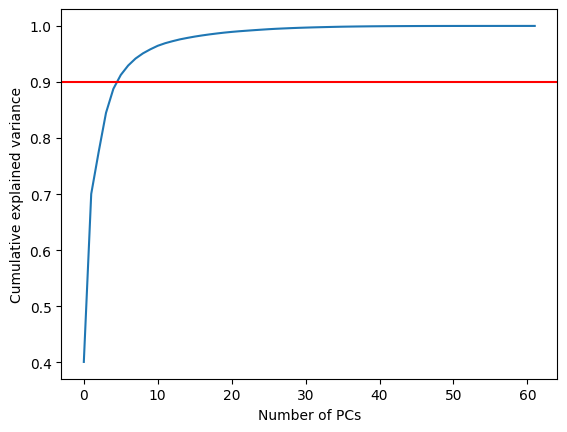

In [5]:
# PCA - principle component analysis

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='red')
plt.show()

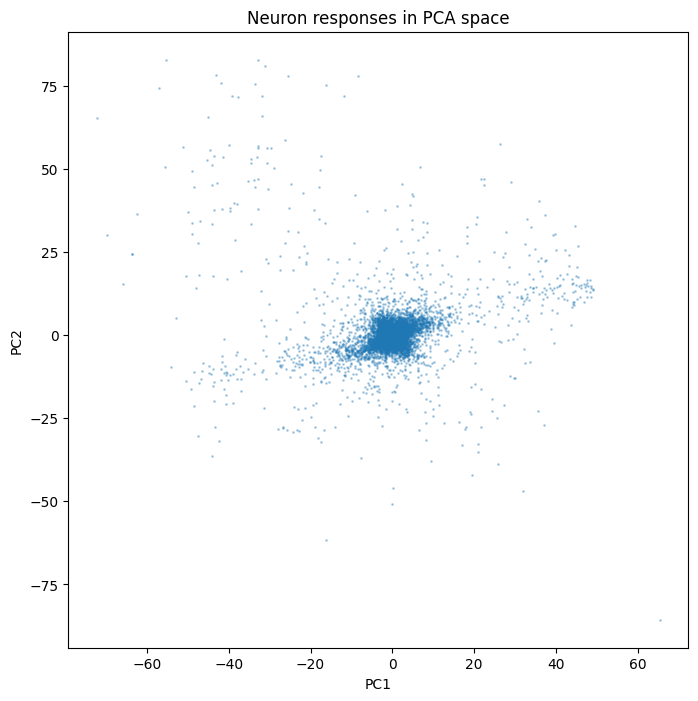

In [7]:
# PCA visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,8))
plt.scatter(X_pca[:,0], X_pca[:,1], s=1, alpha=.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neuron responses in PCA space")
plt.show()

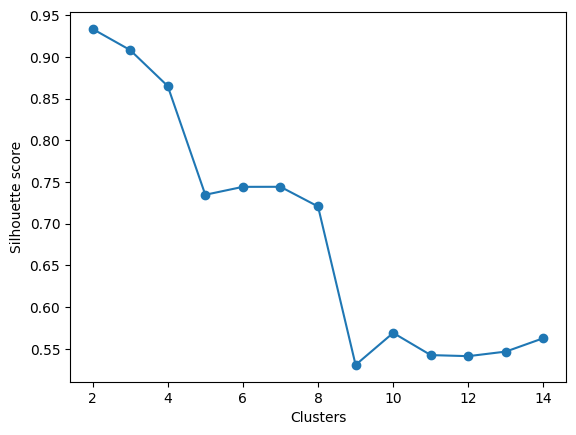

In [8]:
# Test multiple KMeans cluster numbers

cluster_range = range(2, 15)
sil_scores = []

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)

plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Silhouette score")
plt.show()

In [10]:
# Run KMeans with k=7
k=7
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_pca)

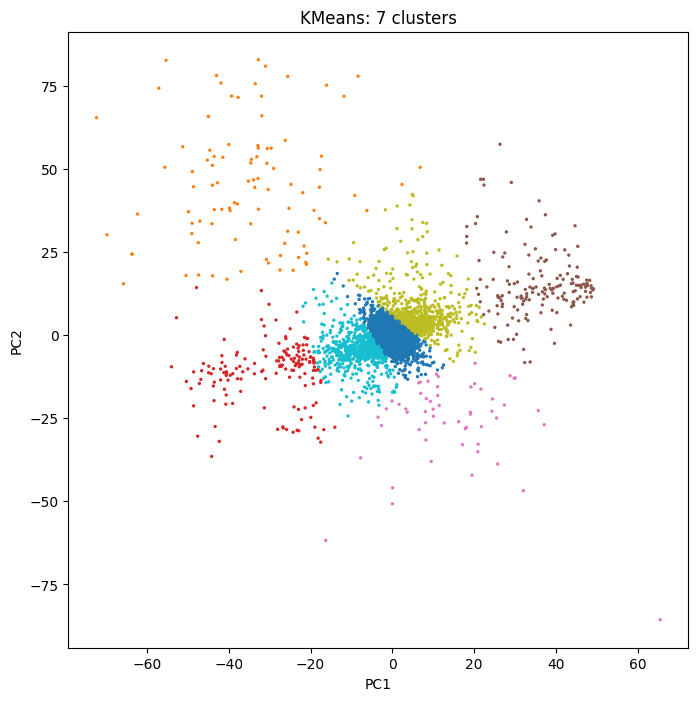

In [11]:
# Plot

plt.figure(figsize=(8,8))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=2, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans: {k} clusters")
plt.show()

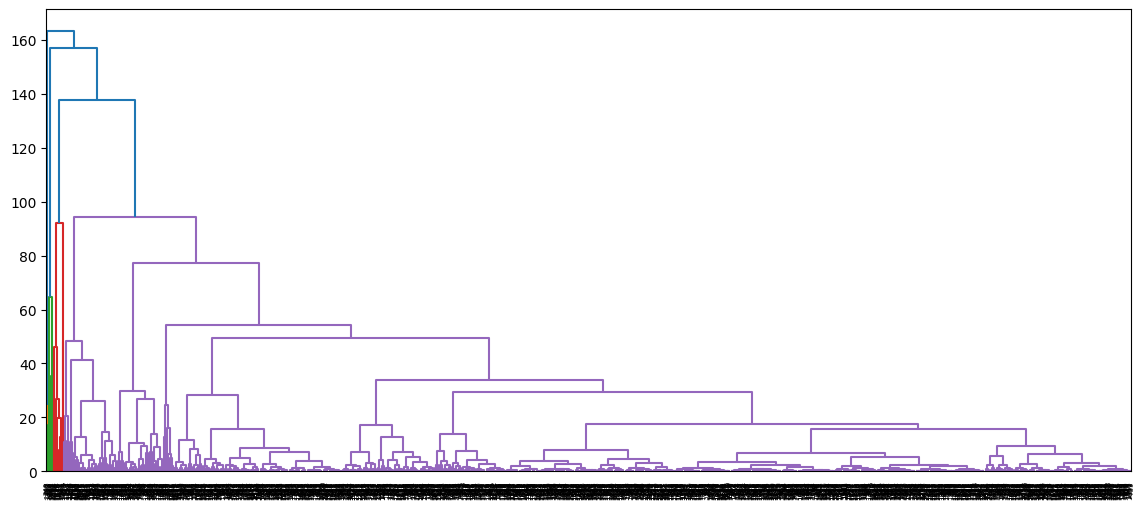

In [12]:
# Hierarchical clustering

sample_idx = np.random.choice(len(X_pca), 2000, replace=False)
X_sample = X_pca[sample_idx]
Z = linkage(X_sample, method="ward")
plt.figure(figsize=(14, 6))
dendrogram(Z)
plt.show()

In [13]:
# Hierarchical labels

labels_h = fcluster(Z, 7, criterion='maxclust')


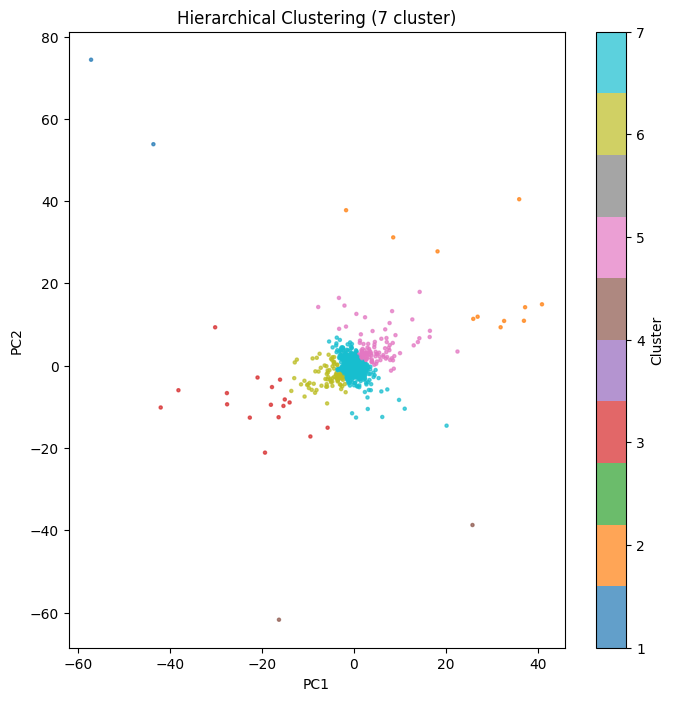

In [14]:
# Plot hierarchical clusters on PCA space

plt.figure(figsize=(8,8))
plt.scatter(X_sample[:,0], X_sample[:,1], c=labels_h, cmap='tab10', s=5, alpha=.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering (7 cluster)")
plt.colorbar(label="Cluster")
plt.show()

In [24]:
# Hierarchical clustering on all rows

hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_hierarchical = hier.fit_predict(X_pca)
labels_hierarchical = labels_hierarchical + 1

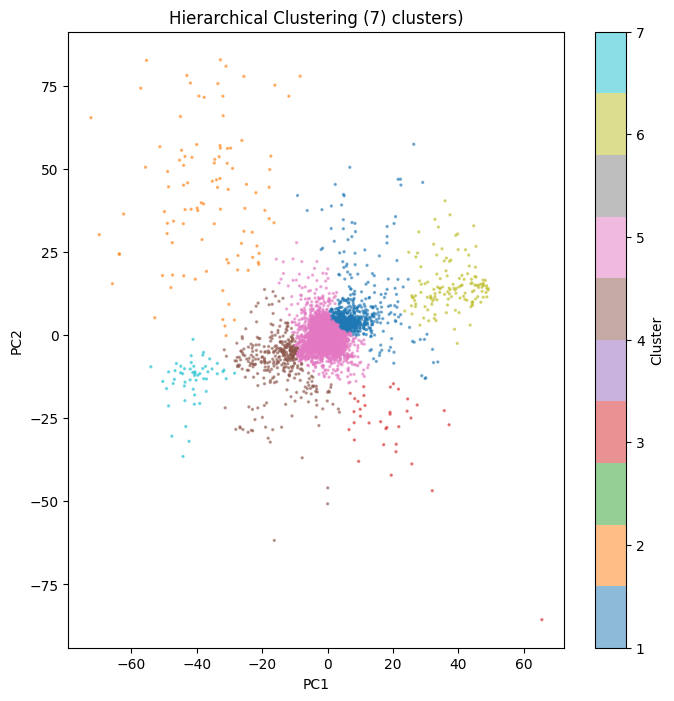

In [26]:
# Plot PCA

plt.figure(figsize=(8,8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hierarchical, cmap="tab10", s=2, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clustering ({k}) clusters)")
plt.colorbar(label="Cluster")
plt.show()

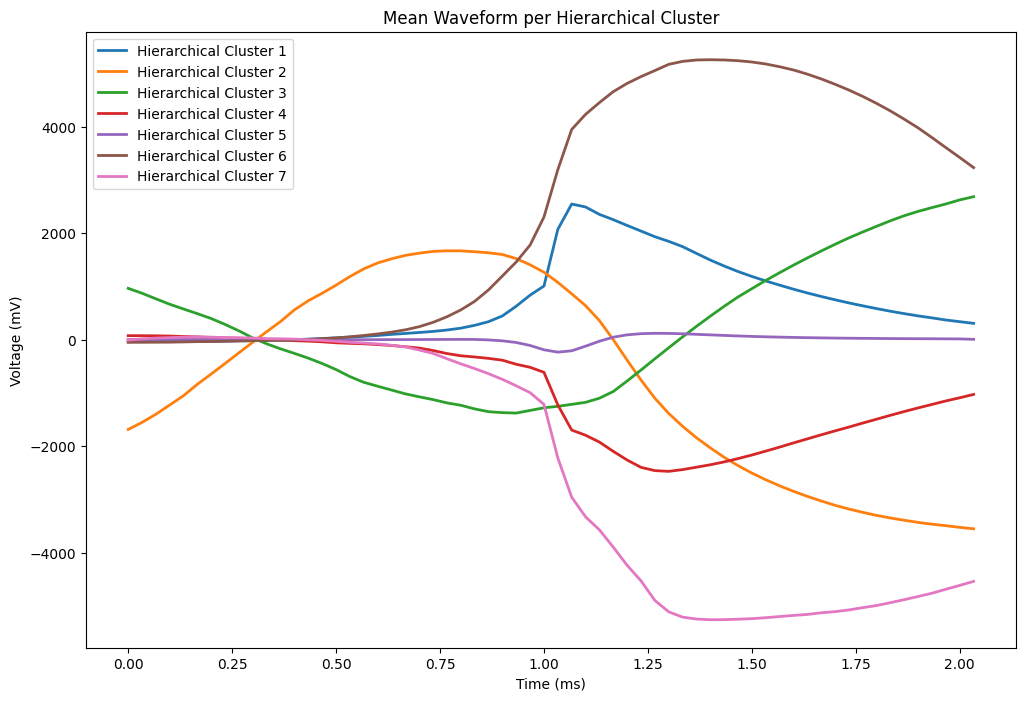

In [27]:
# Mean waveform per hierarchical cluster

plt.figure(figsize=(12, 8))
for cluster in range(1, k+1):
    cluster_waveforms = df.loc[labels_hierarchical == cluster]
    mean_waveform = cluster_waveforms.mean(axis=0)
    plt.plot(time_ms, mean_waveform, linewidth=2, label=f"Hierarchical Cluster {cluster}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Mean Waveform per Hierarchical Cluster")
plt.legend()
plt.show()

In [28]:
# Plot mean waveform per cluster (important biologically)

labels_h = fcluster(Z, 7, criterion='maxclust')

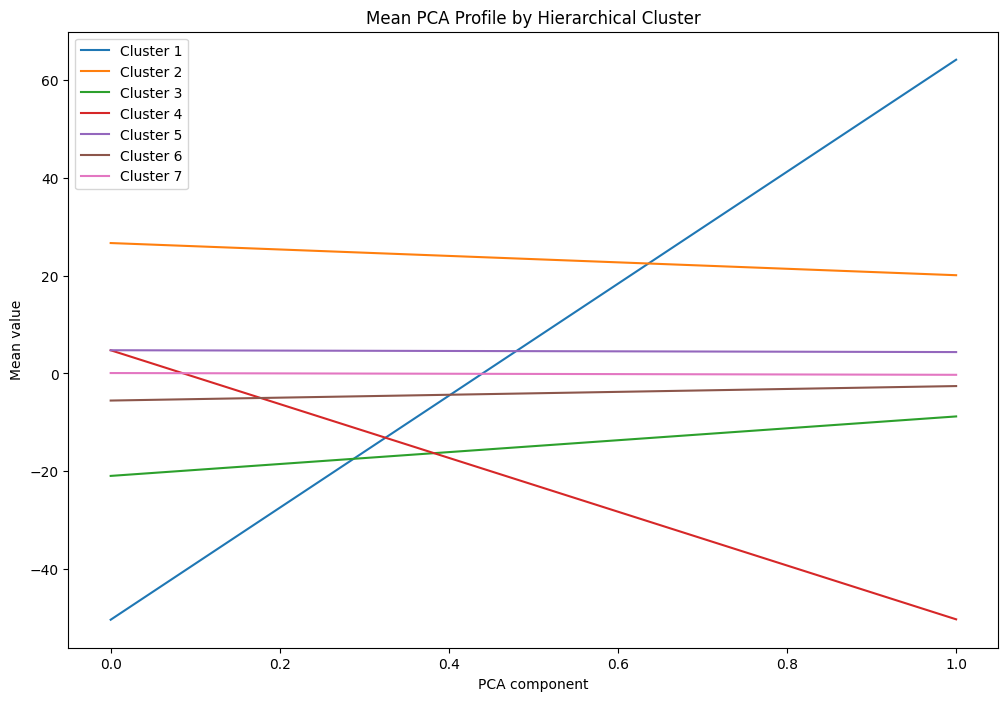

In [16]:
n_clusters = len(np.unique(labels_h))
plt.figure(figsize=(12,8))
for cluster in range(1, n_clusters+1):
    cluster_rows = X_sample[labels_h == cluster]
    mean_waveform = np.mean(cluster_rows, axis=0)
    plt.plot(mean_waveform, label=f"Cluster {cluster}")

plt.xlabel("PCA component")
plt.ylabel("Mean value")
plt.title("Mean PCA Profile by Hierarchical Cluster")
plt.legend()
plt.show()     

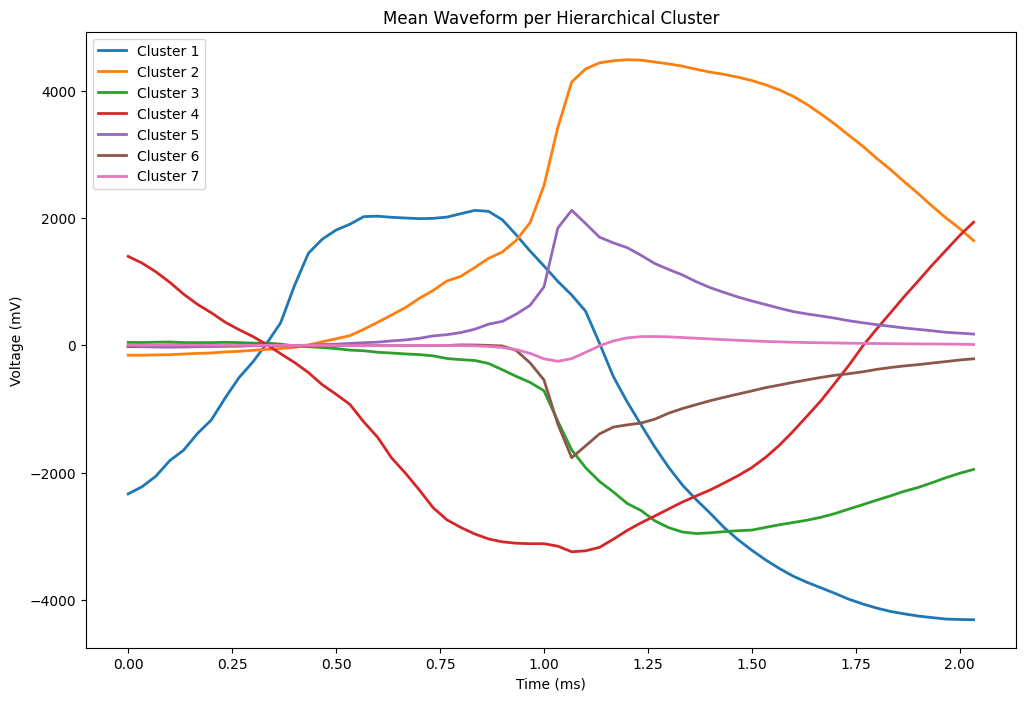

In [20]:
time_ms = np.arange(df.shape[1]) / 30000 * 1000
original_rows = df.iloc[sample_idx].reset_index(drop=True)
labels_h = np.asarray(labels_h)
n_clusters = len(np.unique(labels_h))
plt.figure(figsize=(12,8))

for cluster in range(1, n_clusters+1):
    cluster_waveforms = original_rows[labels_h == cluster]
    mean_waveform = cluster_waveforms.mean(axis=0)
    plt.plot(time_ms, mean_waveform, linewidth=2, label=f"Cluster {cluster}")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Mean Waveform per Hierarchical Cluster")
plt.legend()
plt.show()